In [1]:
# Feature Engineering

In [2]:
# For an online retail dataset, the goal during feature engineering is to translate raw transactions into user-level RFM metrics, product-level attributes, and time-series signals.

# We apply two levels of feature engineering:

# 1. Customer-Level Aggregations (RFM)
# 2. Temporal & Behavioral Features


In [3]:
# 1. Customer-Level Aggregations (RFM)

# Aggregate by Customer ID to build customer profiles for segmentation, churn prediction, or lifetime value models.
# Recency: Days since last purchase relative to the dataset snapshot date.
# Frequency: Count of unique Invoice Number items.
# Monetary Value: Calculate total spend per transaction (Quantity \times Unit Price), then sum or average per customer.
# Returns/Cancellations: Count of negative Quantity records, return frequency, and return value ratio.
# Purchase Diversity: Count of unique Stock Code items or categories purchased.
# Inter-purchase Interval: Average, standard deviation, or median days between consecutive orders.

In [4]:
# 2. Temporal & Behavioral Features

# Extract seasonality and behavioral rhythms from Invoice Date.
# Time-of-Day / Day-of-Week: Distribution of orders placed across hours (morning vs. night) or days (weekday vs. weekend).
# Cyclical Transforms: Encode hour (0 to 23) or month (1 to 12) using sine/cosine transformations to preserve continuity.
# Tenure: Days between a customer’s first purchase and their latest purchase.

In [29]:
# Import packages and libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

In [6]:
# Loading the csv file and check data types
# I call the result dataframe as dff;

dff = pd.read_csv('/content/cleansed_data.csv')

In [7]:
dff.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
dff.dtypes

,0
InvoiceNo,int64
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [9]:
# Let's convert InvoiceDate from object to datetime:

dff['InvoiceDate'] = pd.to_datetime(dff['InvoiceDate'])
dff.dtypes

,0
InvoiceNo,int64
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [10]:

# Initial Data Prep

dff["InvoiceDate"] = pd.to_datetime(dff["InvoiceDate"])
dff["Total Line Value"] = dff["Quantity"] * dff["UnitPrice"]

# Reference date for Recency (1 day after the latest transaction)
snapshot_date = dff["InvoiceDate"].max() + pd.Timedelta(days=1)



# Invoice-Level Aggregations (Aggregated to Customer)

# First, calculate per-invoice metrics
invoice_summary = (
    dff.groupby(["CustomerID", "InvoiceNo"])
    .agg(
        Invoice_Total_Items=("Quantity", "sum"),
        Invoice_Total_Spend=("Total Line Value", "sum"),
        Invoice_Distinct_Products=("StockCode", "nunique"),
        Invoice_Avg_Item_Price=("UnitPrice", "mean"),
        Invoice_Price_Std=("UnitPrice", "std"),
    )
    .reset_index()
)

# Second, average invoice-level behaviors per customer
customer_invoice_features = (
    invoice_summary.groupby("CustomerID")
    .agg(
        Avg_Basket_Size=("Invoice_Total_Items", "mean"),
        Avg_Basket_Value=("Invoice_Total_Spend", "mean"),
        Avg_Basket_Product_Diversity=("Invoice_Distinct_Products", "mean"),
        Avg_Basket_Item_Price=("Invoice_Avg_Item_Price", "mean"),
        Avg_Basket_Price_Variance=("Invoice_Price_Std", "mean"),
    )
    .reset_index()
    .fillna(0)  # Handle NaN variance for single-item baskets
)



# Section 4: Product-Level Attributes (Aggregated to Customer)

# First, calculate product popularity metrics across the entire dataset
product_popularity = (
    dff.groupby("StockCode")["Quantity"].sum().to_dict()
)
dff["Product_Popularity_Score"] = dff["StockCode"].map(product_popularity)

# Second, aggregate customer product preferences & price tier interactions
customer_product_features = (
    dff.groupby("CustomerID")
    .agg(
        Min_Item_Price_Paid=("UnitPrice", "min"),
        Max_Item_Price_Paid=("UnitPrice", "max"),
        Median_Item_Price_Paid=("UnitPrice", "median"),
        Avg_Product_Popularity=("Product_Popularity_Score", "mean"),
    )
    .reset_index()
)



# Base RFM & Temporal Features

dff["Hour"] = dff["InvoiceDate"].dt.hour
dff["DayOfWeek"] = dff["InvoiceDate"].dt.dayofweek
dff["Hour_Sin"] = np.sin(2 * np.pi * dff["Hour"] / 24)
dff["Hour_Cos"] = np.cos(2 * np.pi * dff["Hour"] / 24)

customer_rfm_temporal = (
    dff.groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (snapshot_date - x.max()).days,
        ),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Total Line Value", "sum"),
        Avg_Order_Hour_Sin=("Hour_Sin", "mean"),
        Avg_Order_Hour_Cos=("Hour_Cos", "mean"),
        Weekend_Ratio=("DayOfWeek", lambda x: (x >= 5).mean()),
    )
    .reset_index()
)



# Consolidated Big Table (ML Feature Matrix)

final_customer_features = (
    customer_rfm_temporal.merge(
        customer_invoice_features, on="CustomerID", how="left"
    )
    .merge(customer_product_features, on="CustomerID", how="left")
)

# Export the master feature dataset for Machine Learning
final_customer_features.to_csv(
    "final_customer_ml_features.csv", index=False
)

In [11]:
final_customer_features.head()

,CustomerID,Recency,Frequency,Monetary,Avg_Order_Hour_Sin,Avg_Order_Hour_Cos,Weekend_Ratio,Avg_Basket_Size,Avg_Basket_Value,Avg_Basket_Product_Diversity,Avg_Basket_Item_Price,Avg_Basket_Price_Variance,Min_Item_Price_Paid,Max_Item_Price_Paid,Median_Item_Price_Paid,Avg_Product_Popularity
0,12347.0,33,1,711.79,-0.500000,-0.866025,0.0,319.0,711.79,31.0,2.890000,1.505490,0.65,5.95,3.25,381.870968
1,12348.0,24,1,892.80,-0.965926,0.258819,0.0,1254.0,892.80,13.0,2.917647,9.562247,0.29,40.00,0.55,1115.058824
2,12370.0,24,2,1868.02,0.062163,-0.974251,0.0,484.0,934.01,45.0,5.240617,7.224693,0.65,40.00,2.10,290.296703
3,12377.0,21,1,1001.52,0.707107,-0.707107,0.0,604.0,1001.52,43.0,2.106279,1.424465,0.42,4.95,1.95,372.860465
4,12383.0,19,1,600.72,-0.500000,-0.866025,0.0,754.0,600.72,37.0,1.325135,2.421327,0.12,15.00,0.65,554.918919


In [12]:
final_customer_features.shape

(972, 16)

In [13]:
# As it can be seen, the newly made dataframe has 972 rows and 16 columns.
# This is a totally new table and we will be working with this dataframe for machine learning process.

In [14]:
# Feature Engineering is done, and the above dataframe is our final table for machine learning training.
# Next step is finding a suitable machine learning model.

In [15]:
# Now it is time to introduce a machine learning model.
# For this type of work, the best model is unsupervised distance-based clustering models.
# First, we go for K-Means Clustering.

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [17]:
# 1. Load Data & Separate Identifier

df = pd.read_csv("final_customer_ml_features.csv")

# Keep Customer ID separate to avoid passing it into the model
customer_ids = df["CustomerID"]
X_raw = df.drop(columns=["CustomerID"])

In [18]:
# 2. Preprocessing: Handle Skewness & Scale Features

# Identify features with heavy right-skew (RFM & Monetary/Basket quantities)
# (Offsetting values by adding a small constant or clipping to prevent log(0))
skewed_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "Avg_Basket_Size",
    "Avg_Basket_Value",
    "Avg_Basket_Item_Price",
    "Avg_Basket_Price_Variance",
    "Min_Item_Price_Paid",
    "Max_Item_Price_Paid",
    "Median_Item_Price_Paid",
    "Avg_Product_Popularity",
]

X_prep = X_raw.copy()

# Apply log1p transformation to skewed metrics (log(1 + x) handles 0 values safely)
for col in skewed_cols:
    if col in X_prep.columns:
        # Clip negative monetary values at 0 before taking the log
        X_prep[col] = np.log1p(np.maximum(0, X_prep[col]))


In [19]:

# Scale features so distance-based K-Means treats all variables equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prep)

# Convert back to DataFrame for clean inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X_raw.columns)

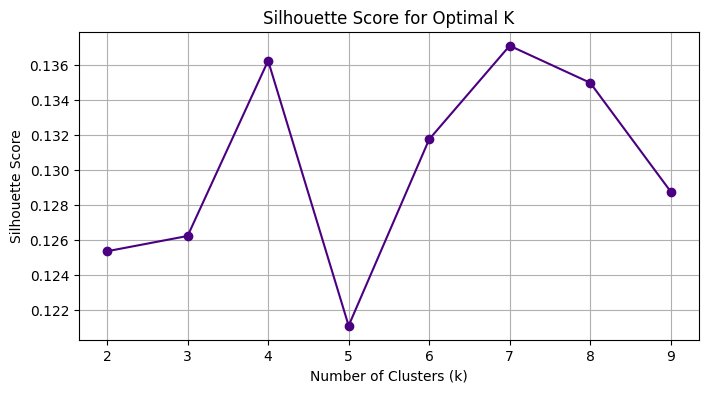

Optimal number of clusters based on Silhouette Score: 7


In [20]:
# 3. Find Optimal K (Silhouette Score Analysis)

silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_test.fit_predict(X_scaled_df)
    score = silhouette_score(X_scaled_df, cluster_labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores to evaluate K
plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker="o", color="indigo")
plt.title("Silhouette Score for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Select optimal K automatically based on maximum silhouette score
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on Silhouette Score: {optimal_k}")

In [21]:
# 4. Train Final K-Means Model

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_scaled_df)

In [22]:
# 5. Segment Summary & Profiling

# Display cluster sizes and average core RFM values per segment
cluster_summary = (
    df.groupby("Cluster")
    .agg(
        Customer_Count=("CustomerID", "count"),
        Recency_Mean=("Recency", "mean"),
        Frequency_Mean=("Frequency", "mean"),
        Monetary_Mean=("Monetary", "mean"),
        Avg_Basket_Value=("Avg_Basket_Value", "mean"),
        Weekend_Ratio=("Weekend_Ratio", "mean"),
    )
    .reset_index()
)

print("\n--- Final Customer Segments Profile ---")
print(cluster_summary)


--- Final Customer Segments Profile ---
   Cluster  Customer_Count  Recency_Mean  Frequency_Mean  Monetary_Mean  \
0        0              94     22.340426        1.340426     374.150745   
1        1             141     12.049645        4.028369    2373.969007   
2        2             237     29.037975        1.308017     319.144852   
3        3             192     26.463542        1.177083     302.439115   
4        4             110     26.554545        1.336364     345.438000   
5        5              58     29.603448        1.224138     201.780000   
6        6             140     25.392857        1.185714     936.220786   

   Avg_Basket_Value  Weekend_Ratio  
0        287.427447       0.948257  
1        659.052277       0.102440  
2        253.585791       0.004469  
3        265.172066       0.010012  
4        273.199773       0.009543  
5        160.483534       0.017241  
6        768.686607       0.051539  


In [23]:
# Export final segmented customers
df.to_csv("customer_segments_final.csv", index=False)

In [24]:
# Let's read the result in pandas format:

# Load your finalized segmented file
df_clustered = pd.read_csv("customer_segments_final.csv")

# Map cluster numbers to meaningful business names (adjust IDs based on your specific cluster_summary output)
segment_mapping = {
    0: "Lost / Hibernating",
    1: "Champions (VIP)",
    2: "At Risk",
    3: "Promising / New",
}

# Add a descriptive column
df_clustered["Segment_Name"] = df_clustered["Cluster"].map(segment_mapping)

# Save the final labeled output
df_clustered.to_csv("customer_segments_labeled.csv", index=False)

In [25]:
df_clustered.head(10)

,CustomerID,Recency,Frequency,Monetary,Avg_Order_Hour_Sin,Avg_Order_Hour_Cos,Weekend_Ratio,Avg_Basket_Size,Avg_Basket_Value,Avg_Basket_Product_Diversity,Avg_Basket_Item_Price,Avg_Basket_Price_Variance,Min_Item_Price_Paid,Max_Item_Price_Paid,Median_Item_Price_Paid,Avg_Product_Popularity,Cluster,Segment_Name
0,12347.0,33,1,711.79,-0.500000,-0.866025,0.0,319.0,711.79,31.0,2.890000,1.505490,0.65,5.95,3.25,381.870968,6,NaN
1,12348.0,24,1,892.80,-0.965926,0.258819,0.0,1254.0,892.80,13.0,2.917647,9.562247,0.29,40.00,0.55,1115.058824,4,NaN
2,12370.0,24,2,1868.02,0.062163,-0.974251,0.0,484.0,934.01,45.0,5.240617,7.224693,0.65,40.00,2.10,290.296703,6,NaN
3,12377.0,21,1,1001.52,0.707107,-0.707107,0.0,604.0,1001.52,43.0,2.106279,1.424465,0.42,4.95,1.95,372.860465,6,NaN
4,12383.0,19,1,600.72,-0.500000,-0.866025,0.0,754.0,600.72,37.0,1.325135,2.421327,0.12,15.00,0.65,554.918919,6,NaN
5,12386.0,4,2,401.90,0.565685,-0.765685,0.0,177.0,200.95,5.0,1.888125,1.320216,0.36,6.75,1.45,241.600000,3,Promising / New
6,12395.0,23,2,679.92,-0.866025,-0.500000,0.0,376.5,339.96,15.5,3.339803,5.265424,0.19,18.00,0.85,698.516129,4,NaN
7,12413.0,3,1,479.25,-0.866025,-0.500000,0.0,180.0,479.25,24.0,5.125000,6.642452,0.65,29.95,2.95,425.166667,4,NaN
8,12415.0,4,1,7011.38,0.258819,-0.965926,0.0,4662.0,7011.38,46.0,1.871304,1.387161,0.37,6.75,1.55,405.043478,6,NaN
9,12417.0,24,1,291.34,0.258819,-0.965926,0.0,60.0,291.34,11.0,7.003636,5.179174,1.69,15.00,3.75,294.727273,2,At Risk


In [26]:
df_final = df_clustered.loc[:, ["CustomerID", 'Cluster', "Segment_Name"]]
df_final.sample(10)

,CustomerID,Cluster,Segment_Name
835,17576.0,4,NaN
53,12725.0,4,NaN
612,16265.0,2,At Risk
830,17551.0,6,NaN
715,16898.0,2,At Risk
426,15139.0,3,Promising / New
138,13178.0,6,NaN
660,16607.0,2,At Risk
739,17026.0,0,Lost / Hibernating
74,12838.0,6,NaN


In [27]:
# Result: K-Means clustering clustered our customers to 6 groups.

In [28]:
# Now, after working with K-Means Clustering, I would like to work with GMM as well.
# GMM stands for Gaussian Mixture Models.
# Some customers may include in two different clusters. GMM gives us a mix of those.
# For example if a customer orders coffee beans, pasta, and a laptop, K-Means only assign one cluster to this customer.
# But GMM assigns a percentage, for example 70% household and 30% Electronics.

In [30]:
from sklearn.mixture import GaussianMixture

# 1. Fit Gaussian Mixture Model with 7 components (matching your K)
gmm = GaussianMixture(n_components=7, random_state=42)
gmm.fit(X_scaled_df)

GaussianMixture(n_components=7, random_state=42)

In [31]:
# 2. Get Hard Cluster Assignments
df["GMM_Cluster"] = gmm.predict(X_scaled_df)

In [32]:
# 3. Get Probabilities (Soft Clustering)
# Returns columns representing the probability of belonging to each of the 7 clusters
probs = gmm.predict_proba(X_scaled_df)
prob_cols = [f"GMM_Prob_Cluster_{i}" for i in range(7)]
probs_df = pd.DataFrame(probs, columns=prob_cols)

In [34]:
# Combine with your main dataset
df_with_gmm = pd.concat([df, probs_df], axis=1)



In [37]:
# Inspect customer #0's cluster probabilities
print(df_with_gmm[["CustomerID", "GMM_Cluster"] + prob_cols].head(10))

   CustomerID  GMM_Cluster  GMM_Prob_Cluster_0  GMM_Prob_Cluster_1  \
0     12347.0            5        6.441843e-51        1.658812e-51   
1     12348.0            5        1.444641e-45       1.986900e-248   
2     12370.0            6        2.321875e-03       3.422874e-165   
3     12377.0            6        3.551591e-61        1.164431e-79   
4     12383.0            5        4.699085e-45        0.000000e+00   
5     12386.0            6        5.035506e-06        5.215997e-35   
6     12395.0            5        1.524007e-02        0.000000e+00   
7     12413.0            5        7.830736e-48        2.313428e-87   
8     12415.0            6        9.223140e-57        4.309506e-67   
9     12417.0            6        6.211948e-48        0.000000e+00   

   GMM_Prob_Cluster_2  GMM_Prob_Cluster_3  GMM_Prob_Cluster_4  \
0        0.000000e+00        6.661706e-20        5.078348e-83   
1        0.000000e+00        1.255306e-33        2.993958e-87   
2        0.000000e+00        9.577

In [38]:
# For each customer_ID we can see group of probabilities.

In [39]:
# At this step, We are done with preprocessign and modeling.
# I used K-Means Clustering and GMM Clustering.
# Silhoutte score shows the optimal number of clusters for K-Means cliustering, which was 7.
# Unlike K-Means, GMM does not have hard clustering. GMM assigns a set of probabilities to each customer.